In [ ]:
!pip install transformers==4.38.2
!pip install torchtext==0.16.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.18.0
    Uninstalling huggingface_hub-1.18.0:
      Successfully uninstalled huggingface_hub-1.18.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the 

# **Import Lib**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchtext
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

In [ ]:
import random
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
set_seed(seed)

In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 10
DROPOUT = 0.3
NUM_CLASSES = 4

# **Load dataset**

In [ ]:
df_train = pd.read_csv("/content/drive/MyDrive/CyberSoft_Courses/ML_DL_04/final_capstone/combine_dataset/train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/CyberSoft_Courses/ML_DL_04/final_capstone/combine_dataset/test.csv")
df_val = pd.read_csv("/content/drive/MyDrive/CyberSoft_Courses/ML_DL_04/final_capstone/combine_dataset/val.csv")

In [ ]:
df_train.head()

,Unnamed: 0,free_text,label_id
0,5621,"Một thời vào sinh ra tử vì đất nước, mang tron...",0
1,14121,Loi ma ba dung chat lun ak,0
2,1495,Hoàng Thị Xuân Phương lệ cay du thiên ý,0
3,1775,Cà khịa :)))),0
4,10011,Giang Nguyen :)),0


In [ ]:
df_train["label_id"].value_counts()

,count
label_id,
0,19888
2,2530
1,1629
3,1440


# **Text Cleaning**

In [ ]:
import re
import unicodedata

def clean_text(text):

    text = str(text)

    # normalize unicode
    text = unicodedata.normalize("NFC", text)

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df_train["free_text"] = df_train["free_text"].apply(clean_text)
df_test["free_text"] = df_test["free_text"].apply(clean_text)
df_val["free_text"] = df_val["free_text"].apply(clean_text)

# **Tokenization**

In [ ]:
# Load tokenize
from transformers import AutoTokenizer

tokenize = AutoTokenizer.from_pretrained("vinai/phobert-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
df_train["label_id"][0]

np.int64(0)

# **Dataset**

In [ ]:
# class SentimentDataset(Dataset):
#     def __init__(
#         self,
#         df,
#         tokenizer,
#         max_len
#     ):
#       self.df = df
#       self.tokenize = tokenize
#       self.max_len = max_len

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, index):
#         text = self.df["free_text"][index]
#         text = tokenize(text)
#         text = torch.tensor(text, dtype=torch.long)
#         label = self.df["label_id"][index]
#         label = torch.tensor(label, dtype=torch.long)
#         return text, label

class SentimentDataset(Dataset):

    def __init__(
        self,
        df,
        tokenizer,
        max_len
    ):

        self.df = df

        self.tokenizer = tokenizer

        self.max_len = max_len

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        # lấy text
        text = str(
            self.df.iloc[index]["free_text"]
        )

        # lấy label
        label = int(
            self.df.iloc[index]["label_id"]
        )

        # tokenize
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        # return data
        return {

            "input_ids": encoding[
                "input_ids"
            ].flatten(),

            "attention_mask": encoding[
                "attention_mask"
            ].flatten(),

            "label": torch.tensor(
                label,
                dtype=torch.long
            )
        }

In [ ]:
# Create dataset
train_dataset = SentimentDataset(
    df_train,
    tokenize,
    MAX_LEN
)

test_dataset = SentimentDataset(
    df_test,
    tokenize,
    MAX_LEN
)

val_dataset = SentimentDataset(
    df_val,
    tokenize,
    MAX_LEN
)

# **Dataloader**

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# **Pretrained Model: PhoBert**

In [ ]:
from transformers import AutoModel

class PhoBert(nn.Module):

    def __init__(
        self,
        dropout_p=0.3,
        num_classes=5
    ):

        super().__init__()

        self.embedding = AutoModel.from_pretrained(
            "vinai/phobert-base"
        )

        # self.dropout = nn.Dropout(
        #     dropout_p
        # )

        # self.fc = nn.Linear(
        #     768,
        #     num_classes
        # )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes)
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.embedding(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # lấy CLS token
        cls_output = outputs.last_hidden_state[:, 0, :]

        logits = self.classifier(cls_output)

        return logits

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Model
model = PhoBert(
    dropout_p=DROPOUT,
    num_classes=NUM_CLASSES
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

# **Freeze transformer blocks of PhoBert model (Because of Small Dataset)**

In [ ]:
def freeze_transformer_blocks_model(model):
    for param in model.embedding.parameters():
        param.requires_grad = False
    return model

In [ ]:
# freeze_model = freeze_transformer_blocks_model(model)

# **Optimizer & Criterion**

In [ ]:
# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Class_weight for imbalance data
classes = np.unique(df_train["label_id"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label_id"]
)

weights = torch.tensor(weights, dtype=torch.float)
weights = torch.sqrt(weights)
weights = weights / weights.sum()
class_weights = weights.to(device)

# Criterion
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Học chậm lại để học kỹ các faetures hơn
# Scheduler
scheduler_step_size = EPOCHS * 0.8
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=scheduler_step_size, # Bước thứ mấy (epoch mấy) thì thay đổi
    gamma=0.1 # lr_new = lr * gamma
)

# **Train Function**

In [ ]:
def train(
    model,
    train_loader,
    optimizer,
    criterion,
    device
):

    model.train()

    train_loss = []

    train_acc = []

    for batch in train_loader:

        # lấy data từ batch
        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        # forward
        preds = model(
            input_ids,
            attention_mask
        )

        # compute loss
        loss = criterion(
            preds,
            labels
        )

        train_loss.append(
            loss.item()
        )

        # accuracy
        pred_labels = torch.argmax(
            preds,
            dim=1
        )

        acc = (
            pred_labels == labels
        ).sum().item() / len(labels)

        train_acc.append(acc)

        # backward
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    total_loss = sum(train_loss) / len(train_loss)

    total_acc = sum(train_acc) / len(train_acc)

    return total_loss, total_acc

# **Eval Function**

In [ ]:
def eval(
    model,
    val_loader,
    criterion,
    device
):

    model.eval()

    val_loss = []

    correct = 0

    total = 0

    with torch.inference_mode():

        for batch in val_loader:

            # lấy data
            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            labels = batch[
                "label"
            ].to(device)

            # forward
            outputs = model(
                input_ids,
                attention_mask
            )

            # loss
            loss = criterion(
                outputs,
                labels
            )

            val_loss.append(
                loss.item()
            )

            # prediction
            preds = torch.argmax(
                outputs,
                dim=1
            )

            # accuracy
            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    total_loss = sum(val_loss) / len(val_loss)

    total_acc = correct / total

    return total_loss, total_acc

# **Training Model**

In [ ]:
model = model.to(device)
best_val_loss = float("inf")
train_loss_history, val_loss_history = [], []
for epoch in range(EPOCHS):
    start_time = time.time()
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)

    train_loss, train_acc = train(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = eval(
        model,
        val_loader,
        criterion,
        device
    )
    end_time = time.time()

    print(f"Train Loss: {train_loss:.2f} | Train Acc: {train_acc:.2f} | Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.2f} (Time: {end_time-start_time:.2f}s)")

    scheduler.step()

    if best_val_loss > val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/drive/MyDrive/CyberSoft_Courses/ML_DL_04/final_capstone/models/best_phobert_model.pth")
        print(f"Saved best model at epoch {epoch + 1}")

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

Epoch 1/10
----------
Train Loss: 0.68 | Train Acc: 0.82 | Val Loss: 0.64 | Val Acc: 0.77 (Time: 638.60s)
Saved best model at epoch 1
Epoch 2/10
----------
Train Loss: 0.52 | Train Acc: 0.85 | Val Loss: 0.51 | Val Acc: 0.86 (Time: 651.71s)
Saved best model at epoch 2
Epoch 3/10
----------
Train Loss: 0.46 | Train Acc: 0.86 | Val Loss: 0.57 | Val Acc: 0.83 (Time: 650.00s)
Epoch 4/10
----------
Train Loss: 0.40 | Train Acc: 0.88 | Val Loss: 0.56 | Val Acc: 0.81 (Time: 649.86s)
Epoch 5/10
----------
Train Loss: 0.36 | Train Acc: 0.89 | Val Loss: 0.54 | Val Acc: 0.85 (Time: 650.09s)
Epoch 6/10
----------
Train Loss: 0.33 | Train Acc: 0.90 | Val Loss: 0.60 | Val Acc: 0.83 (Time: 650.72s)
Epoch 7/10
----------
Train Loss: 0.29 | Train Acc: 0.91 | Val Loss: 0.75 | Val Acc: 0.85 (Time: 650.04s)
Epoch 8/10
----------
Train Loss: 0.28 | Train Acc: 0.91 | Val Loss: 0.68 | Val Acc: 0.83 (Time: 649.22s)
Epoch 9/10
----------
Train Loss: 0.21 | Train Acc: 0.94 | Val Loss: 0.77 | Val Acc: 0.84 (Time:

# **Loss Plot**

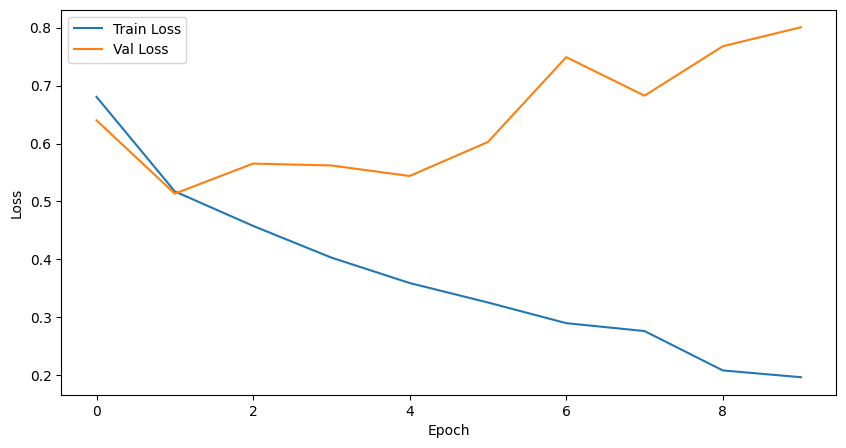

In [ ]:
# Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()